# Monte Carlo Simulation of the q-state Potts model


---

### Author: Roland Hansson

### Group: 9

### BERN01 2026 Spring term

## Abstract
We coded a representation of a Potts Model, and three different Monte Carlo algorithms for updating it. We then investigated their properties, to better compare them and determine their utility.
The work was done in Python.

## Introduction
The Potts model models a system as a lattice of nodes with four neighbours.
The nodes can each have one of q states.
The energy of the lattice depends simply on how many of the neighbour-to-neighbour connections that have equal states on each side.


![Potts](/content/potts_evolution_cold_start.gif)

The system evolves over time, seeking a lower energy state.
Ideally, the model would update each node every tick, taking into account the energies involved, but this would take too much computer power.
Instead, algorithms are used to effect random changes - but according to equations forcing such changes to follow roughly the same patterns observed in nature.  

frames:  100


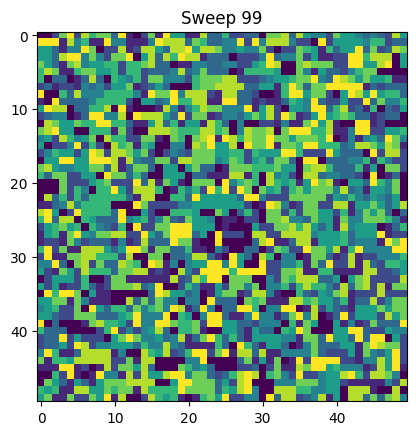

'\n##############\ncold_matrix = np.zeros((50,50))\nhot_matrix = arr = np.random.randint(0, 10, size=(50,50))\nframes=[]\n#energy1 = energy\nenergy = []\n\nT=0.5\nfor i in range(0,100):\n    update_matrix(cold_matrix, T, max_val=9)\n\nfig, ax = plt.subplots()\nim = ax.imshow(frames[0], vmin=0, vmax=frames[0].max(), animated=True)\n\ndef update(frame_idx):\n    im.set_array(frames[frame_idx])\n    ax.set_title(f"Sweep {frame_idx}")\n    return [im]\n\nani = FuncAnimation(fig, update, frames=len(frames), interval=100, blit=True)\nani.save("potts_evolution_cold_start_mid_T.gif", writer="pillow", fps=10)\nplt.show()\n\nenergy = [-e for e in energy]\n#plt.plot(energy1)\nplt.plot(energy)\nplt.show()\n'

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
@author: Roland Hansson
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

frames=[]
energy=[]
density={}
visits={}

class PottsMatrix:
  def __init__(self, row_len=3, col_len=3, max_val=1, T=1, start='cold'):
    self.col_len = col_len
    self.row_len = row_len
    self.T = T
    self.max_val = max_val
    self.data = np.zeros((row_len,col_len), dtype=int)
    if start=='hot':
      self.data = np.random.randint(0, max_val+1, size=(row_len,col_len) )
    self.frames=[]
    self.energy=[]
    self.density={}
    self.visits={}

  def show_matrix(self):
    plt.show()

  def index(self):
    row_len, col_len = self.row_len, self.col_len
    idx = np.array(range(row_len * col_len))
    rows, cols = np.unravel_index(idx, (row_len, col_len))
    index = zip(rows,cols)
    return index

  def shuffled_index(self):
    row_len, col_len = self.row_len, self.col_len
    idx = np.random.permutation(row_len * col_len)
    rows, cols = np.unravel_index(idx, (row_len, col_len))
    index = zip(rows,cols)
    return index

  def get_proposed_value(self, current_value):
        choices = [x for x in range(self.max_val + 1) if x != current_value]
        return np.random.choice(choices)

  def get_original_energy(self, original_value, neighbour_values):
      original_energy=0
      for i in neighbour_values:
          if original_value == i: original_energy = original_energy + 1
      return original_energy

  def get_energy(self, original_value, proposed_value, neighbour_values):
      original_energy=0
      proposed_energy=0
      for i in neighbour_values:
          if original_value == i: original_energy = original_energy + 1
          if proposed_value == i: proposed_energy = proposed_energy + 1
      delta = original_energy - proposed_energy
      return original_energy, proposed_energy, delta

  def get_probability(self, original_value, proposed_value, neighbour_values,T=1):
      original_energy=0
      proposed_energy=0
      T = self.T
      B=1/T
      for i in neighbour_values:
          if original_value == i: original_energy = original_energy + 1
          if proposed_value == i: proposed_energy = proposed_energy + 1
      delta = original_energy - proposed_energy
      p = np.exp(-B*delta)
      #print(original_value, proposed_value, neighbour_values, delta, p)
      return p

  def get_density(self,E):
      global density
      if E in density: return density[E]
      return 0

  def update_density(self,E, f):
      global density
      if E in density: density[E] += np.log(f)
      else: density[E]=np.log(f)

  def get_visits(self,E,visits):
      if E in visits: return visits[E]
      return 0

  def update_visits(self,E, visits):
      if E in visits: visits[E] += 1
      else: visits[E]=1

  def get_wang_probability(self, original_value, proposed_value, neighbour_values,E):
      T = self.T
      original_energy, proposed_energy, delta = self.get_energy(original_value, proposed_value, neighbour_values)
      density_original = self.get_density(E)
      proposed_total_energy = E - 2 * delta
      density_proposed = self.get_density(proposed_total_energy)
      if density_proposed == 0: return 2, proposed_total_energy
      return density_original/density_proposed, proposed_total_energy

  def get_neighbours(self,i):
      #print(i)
      x=i[0]
      y=i[1]
      row_len, col_len = self.row_len, self.col_len
      m = self.data
      neighbours = [
      m[(x-1) % row_len, y],
      m[(x+1) % row_len, y],
      m[x, (y-1) % col_len],
      m[x, (y+1) % col_len],
      ]
      return neighbours

  def get_total_energy(self):
      m = self.data
      #print(m)
      temp_index = self.index()
      #print(temp_index)
      E=0
      for i in temp_index:
          #print(i)
          original_value = m[i]
          neighbour_values = self.get_neighbours(i)
          original_e = self.get_original_energy(original_value,neighbour_values)
          E += original_e
      return E


  def get_heat_bath_value(self, neighbour_values):
    T = self.T
    q = self.max_val + 1
    beta = 1/T
    counts = np.zeros(q)

    for v in neighbour_values:
        counts[v] += 1

    weights = np.exp(beta * counts)
    probs = weights / weights.sum()
    return np.random.choice(q, p=probs)


  def visit_density_is_flat(self,visits, threshold=0.8):
      list_visits = np.array(list(visits.values()), dtype=float)
      return list_visits.min() >= threshold * list_visits.mean()

  def metropolis(self, E=0):
      max_val = self.max_val
      m = self.data
      T = self.T
      if E==0: E = self.get_total_energy()
      self.energy.append(E)

      temp_index = self.shuffled_index()
      for i in temp_index:
          original_value = m[i]
          proposed_value = self.get_proposed_value(original_value)
          neighbour_values = self.get_neighbours(i)
          original_e, proposed_e, delta_e = self.get_energy(original_value, proposed_value, neighbour_values)
          B=1/T
          probability = np.exp(-B*delta_e)

          if probability > 1:
              m[i] = proposed_value
              E = E + delta_e
              continue

          decision = (probability>=np.random.rand())
          if decision:
              m[i] = proposed_value
      self.frames.append(m.copy())
      #energy.append(E)
      return m

  def wang_landau(self,epsilon=0.001):
      global visits
      f=np.e
      nr=0
      m = self.data
      while f > 1 + epsilon:
          nr += 1
          sub_nr=0
          print("round", nr, " f=", f)
          temp_index = self.shuffled_index(m)
          E = self.get_total_energy()
          for i in temp_index:
              sub_nr += 1
              if sub_nr %100 == 0: print(".", end='')
              self.update_visits(E,visits)
              self.update_density(E,f)

              original_value = m[i]
              proposed_value = self.get_proposed_value(original_value)
              neighbour_values = self.get_neighbours(i,m)
              probability, proposed_total_energy = self.get_wang_probability(original_value, proposed_value, neighbour_values, E)

              if probability > 1:
                  m[i] = proposed_value
                  E = proposed_total_energy
                  continue

              decision = (probability>=np.random.rand())
              if decision:
                  m[i] = proposed_value
                  E = proposed_total_energy

          frames.append(m.copy())
          if self.visit_density_is_flat(visits):
              f = f**0.5
              visits.clear()
      return density

  def heat_bath(self):
      m = self.data
      E = self.get_total_energy()
      self.energy.append(E)

      temp_index = self.shuffled_index()
      for i in temp_index:
          original_value = m[i]
          neighbour_values = self.get_neighbours(i)
          m[i] = self.get_heat_bath_value(neighbour_values)
      self.frames.append(m.copy())
      return m

  def update_matrix(self, setting='metropolis', epsilon=0.05):
      if setting=='metropolis': return self.metropolis()
      elif setting=='wang_landau':  return self.wang_landau(epsilon)
      elif setting=='heat_bath':  return self.heat_bath()
      elif setting=='heat-bath':  return self.heat_bath()
      elif setting=='wang-landau':  return self.wang_landau(epsilon)
      else: exit("unknown setting!")


###############################
###############################
###############################



binary_matrix = np.zeros((50,50))
deka_matrix = np.zeros((10,10))

M = PottsMatrix(row_len=10, col_len=10, max_val=9, T=0.5)
M.update_matrix(setting='metropolis')
M.show_matrix()

"""
T=1
update_matrix(deka_matrix, T ,max_val=9, setting='wang_landau', epsilon=0.05)
print(density)

x=[]
y=[]
for key, value in density.items():
    y.append(np.log(key))
    x.append(np.log(value))
plt.scatter(y,x)
plt.show()

x=[]
y=[]
for key, value in visits.items():
    y.append(np.log(key))
    x.append(np.log(value))
plt.scatter(y,x)
plt.show()
"""


#matrix_cold_to_cold = PottsMatrix(row_len=50, col_len=50, max_val=9, T=0.5, start='cold')
matrix_cold_to_hot = PottsMatrix(row_len=50, col_len=50, max_val=9, T=0.9, start='cold')
#matrix_hot_to_cold = PottsMatrix(row_len=50, col_len=50, max_val=9, T=0.1, start='hot')
#matrix_hot_to_hot = PottsMatrix(row_len=50, col_len=50, max_val=9, T=0.9, start='hot')

T=0.95
for i in range(0,100):
    matrix_cold_to_hot.update_matrix(setting='heat-bath')

fig, ax = plt.subplots()
frames = matrix_cold_to_hot.frames
print("frames: ", len(frames))

im = ax.imshow(frames[0], vmin=0, vmax=frames[0].max(), animated=True)

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_title(f"Sweep {frame_idx}")
    return [im]

ani = FuncAnimation(fig, update, frames=len(frames), interval=100, blit=True)
ani.save("potts_evolution_cold_start.gif", writer="pillow", fps=10)
plt.show()


"""
##############
cold_matrix = np.zeros((50,50))
hot_matrix = arr = np.random.randint(0, 10, size=(50,50))
frames=[]
#energy1 = energy
energy = []

T=0.5
for i in range(0,100):
    update_matrix(cold_matrix, T, max_val=9)

fig, ax = plt.subplots()
im = ax.imshow(frames[0], vmin=0, vmax=frames[0].max(), animated=True)

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_title(f"Sweep {frame_idx}")
    return [im]

ani = FuncAnimation(fig, update, frames=len(frames), interval=100, blit=True)
ani.save("potts_evolution_cold_start_mid_T.gif", writer="pillow", fps=10)
plt.show()

energy = [-e for e in energy]
#plt.plot(energy1)
plt.plot(energy)
plt.show()
"""

## Results

### Metropolis
